# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz

**Fecha:** 1 de Mayo de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie usando una arquitectura pre-entrenada RESNET

## 1. Importe de Librerias

In [4]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import zipfile
import shutil
import seaborn as sns
import datetime
import cv2

import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [5]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-05-01 18:38:17.616506


## 2. Definción de Rutas y Parámetros

In [7]:
data_dir = 'Datos Finales Enfermedad Balanceados'  # Reemplaza con la ruta real
metadata_file = 'archivos_datos_balanceados_enfermedad.csv' # Reemplaza con la ruta real
image_height = 150
image_width = 150
batch_size = 15
num_classes = None  # Se determinará automáticamente del archivo CSV

## 3. Cargar y procesar los metadatos

In [9]:
try:
    metadata = pd.read_csv(metadata_file, sep=";")
    metadata["Planta_Condición_Enfermedad"] = metadata["Planta_Estado"] + "_" + metadata["Condición"]
    metadata = metadata.rename(columns={'Nombre del archivo': 'image_id'})
    
    # Asegúrate de que las columnas 'filename' (o el nombre de tu columna de nombres de archivo)
    # y 'label' (o el nombre de tu columna de etiquetas) existan.
   
    if 'image_id' not in metadata.columns or 'Planta_Condición_Enfermedad' not in metadata.columns:
        raise ValueError("El archivo CSV debe contener las columnas 'image_id' y 'Planta'.")
    class_names = metadata['Planta_Condición_Enfermedad'].unique().tolist()
    num_classes = len(class_names)
    print(f"Se encontraron {num_classes} clases: {class_names}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo de metadatos en '{metadata_file}'.")
    exit()
except ValueError as e:
    print(f"Error al procesar el archivo CSV: {e}")
    exit()

Se encontraron 37 clases: ['Strawberry_healthy_healthy', 'Cauliflower_sick_bacterial_spot_rot', 'Potato_sick_Early_blight', 'Corn_healthy_healthy', 'Tomato_sick_Target_Spot', 'Potato_sick_Late_blight', 'Tomato_sick_Late_blight', 'Tomato_sick_Tomato_mosaic_virus', 'Cassava_sick_Cassava_Brown_Streak_Disease_(CBSD)', 'Tomato_sick_Leaf_Mold', 'Cauliflower_healthy_healthy', 'Apple_sick_Cedar_apple_rust', 'Tomato_sick_Bacterial_spot', 'Cassava_sick_Cassava_Bacterial_Blight_(CBB)', 'Cassava_sick_Cassava_Green_Mottle_(CGM)', 'Tomato_sick_Early_blight', 'Corn_sick_Common_rust', 'Cucumber_healthy_healthy', 'Tomato_healthy_healthy', 'Cassava_healthy_healthy', 'Cauliflower_sick_black_rot', 'Tomato_sick_Tomato_Yellow_Leaf_Curl_Virus', 'Apple_sick_Apple_scab', 'Corn_sick_Northern_Leaf_Blight', 'Bean_healthy_healthy', 'Tomato_sick_Spider_mites Two-spotted_spider_mite', 'Bean_sick_angular_leaf_spot', 'Cauliflower_sick_downy_mildew', 'Tomato_sick_Septoria_leaf_spot', 'Corn_sick_Cercospora_leaf_spot Gra

In [10]:
train, test= train_test_split(metadata, test_size=0.2, random_state=42,shuffle=True, stratify=metadata['Planta_Condición_Enfermedad'])
train.shape, test.shape

((8880, 7), (2220, 7))

In [11]:
train.Planta_Condición_Enfermedad.value_counts()

Planta_Condición_Enfermedad
Strawberry_healthy_healthy                          240
Tomato_sick_Leaf_Mold                               240
Cauliflower_sick_downy_mildew                       240
Potato_sick_Late_blight                             240
Cassava_sick_Cassava_Mosaic_Disease_(CMD)           240
Apple_healthy_healthy                               240
Bean_sick_angular_leaf_spot                         240
Corn_sick_Cercospora_leaf_spot Gray_leaf_spot       240
Potato_sick_Early_blight                            240
Corn_sick_Common_rust                               240
Tomato_sick_Tomato_mosaic_virus                     240
Cassava_healthy_healthy                             240
Cucumber_sick_diseased                              240
Strawberry_sick_Leaf_scorch                         240
Cassava_sick_Cassava_Bacterial_Blight_(CBB)         240
Tomato_sick_Spider_mites Two-spotted_spider_mite    240
Tomato_sick_Bacterial_spot                          240
Tomato_sick_Early_bl

## 4. Crear un generador de datos

In [13]:
datagen = ImageDataGenerator(
    validation_split = 0.2,
    preprocessing_function = None,
    rotation_range = 45,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
    shear_range = 0.1,
    height_shift_range = 0.1,
    width_shift_range = 0.1
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Condición_Enfermedad',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  # Importante para clasificación multiclase
    subset='training',
    seed=42,
    classes=class_names  # Asegurarse del orden de las clases
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Condición_Enfermedad',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42,
    classes=class_names
)

Found 7104 validated image filenames belonging to 37 classes.
Found 1775 validated image filenames belonging to 37 classes.


## 5. Cargar el modelo ResNet50 preentrenado (sin la capa superior de clasificación)

In [15]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(image_height, image_width, 3))

## 6. Congelar las capas convolucionales base

In [17]:
for layer in base_model.layers:
    layer.trainable = False

## 7. Añadir una nueva capa de clasificación personalizada

In [19]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
# Puedes añadir más capas densas aquí si lo deseas
# x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

## 8. Crear el modelo final

In [21]:
model = Model(inputs=base_model.input, outputs=predictions)

## 9. Compilar el modelo para fine-tuning de la última capa

In [23]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

## 10. Entrenar el modelo con la última capa descongelada

In [25]:
epochs_fine_tune = 20  # Define el número de épocas para el fine-tuning

In [26]:
print("Comenzando el entrenamiento de la última capa...")
history_fine_tune = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=epochs_fine_tune,
    verbose = 1
)

Comenzando el entrenamiento de la última capa...
Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 160s 334ms/step - accuracy: 0.4805 - loss: 1.8992 - val_accuracy: 0.7136 - val_loss: 0.8998
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.7333 - loss: 0.9276 - val_accuracy: 0.7136 - val_loss: 0.8606
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 166s 352ms/step - accuracy: 0.7645 - loss: 0.6992 - val_accuracy: 0.7910 - val_loss: 0.6364
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 49s 102ms/step - accuracy: 0.7333 - loss: 0.6889 - val_accuracy: 0.7768 - val_loss: 0.6538
Epoch 5/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 172s 363ms/step - accuracy: 0.7868 - loss: 0.6224 - val_accuracy: 0.7977 - val_loss: 0.6311
Epoch 6/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 35s 73ms/step - accuracy: 0.7333 - loss: 0.6264 - val_accuracy: 0.7927 - val_loss: 0.6435
Epoch 7/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 176s 371ms/step - accuracy: 0.8259 - loss: 0.4958 - val_accuracy: 0.7870 - val_loss: 0.6898
Epoch 8/20
473/473 ━━━━━━━━━━━━━

In [27]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-05-01 19:13:52.402515
Duración: 0:35:34.786009


## 11. Opcional: Descongelar algunas de las últimas capas del modelo base para un fine-tuning más profundo

In [29]:
# unfreeze_layers = 5  # Número de capas a descongelar (contando desde la última convolucional)

# for layer in base_model.layers[-unfreeze_layers:]:
#     layer.trainable = True


## 12. Opcional: Recompilar el modelo después de descongelar las capas

In [31]:
#model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Usar un learning rate menor
#              loss='categorical_crossentropy',
#              metrics=['accuracy'])

## 13. Opcional: Entrenar el modelo con las capas descongeladas

In [33]:
#epochs_deep_fine_tune = 5  # Define el número de épocas para el fine-tuning profundo

#print(f"\nComenzando el fine-tuning profundo de las últimas {unfreeze_layers} capas...")
#history_deep_fine_tune = model.fit(
#    train_generator,
#    steps_per_epoch=train_generator.samples // train_generator.batch_size,
#    validation_data=validation_generator,
#    validation_steps=validation_generator.samples // validation_generator.batch_size,
#    epochs=epochs_deep_fine_tune
#)

## 14. Evaluar el modelo final

In [35]:
print("\nEvaluando el modelo...")
evaluation_result = model.evaluate(validation_generator)
print(f"Pérdida en la validación: {evaluation_result[0]:.4f}")
print(f"Precisión en la validación: {evaluation_result[1]:.4f}")


Evaluando el modelo...
119/119 ━━━━━━━━━━━━━━━━━━━━ 37s 312ms/step - accuracy: 0.8436 - loss: 0.5301
Pérdida en la validación: 0.5579
Precisión en la validación: 0.8389


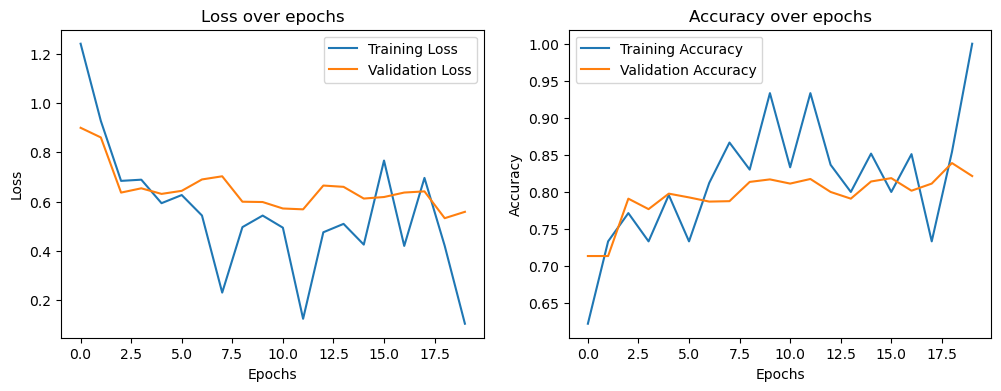

In [36]:
# Acceder a los datos de pérdida y precisión
loss = history_fine_tune.history['loss']
val_loss = history_fine_tune.history['val_loss']
accuracy = history_fine_tune.history['accuracy']
val_accuracy = history_fine_tune.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['loss'], label='Training Loss')
plt.plot(history_fine_tune.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [37]:
epochs = list(range(1, 21))
data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

    Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0       1        1.241552         0.899805           0.622232   
1       2        0.927643         0.860607           0.733333   
2       3        0.683983         0.636398           0.771477   
3       4        0.688853         0.653810           0.733333   
4       5        0.593322         0.631084           0.795881   
5       6        0.626388         0.643537           0.733333   
6       7        0.543175         0.689832           0.812244   
7       8        0.229845         0.702656           0.866667   
8       9        0.495978         0.599311           0.830159   
9      10        0.543004         0.598017           0.933333   
10     11        0.493766         0.571747           0.833263   
11     12        0.123384         0.568285           0.933333   
12     13        0.475072         0.665038           0.836648   
13     14        0.509203         0.659755           0.800000   
14     15        0.424920

In [38]:
# Accuracy final en entrenamiento
val_loss = history_fine_tune.history['val_loss'][-1]

In [39]:
print('Perdida final en Train:', history_fine_tune.history['loss'][-1])
print("Pérdida final en Validation:", history_fine_tune.history['val_loss'][-1])


print("Accuracy final en Train:", history_fine_tune.history['accuracy'][-1])
print("Accuracy final en Validation:", history_fine_tune.history['val_accuracy'][-1])

Perdida final en Train: 0.10332369059324265
Pérdida final en Validation: 0.5582188963890076
Accuracy final en Train: 1.0
Accuracy final en Validation: 0.8214689493179321


In [40]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
print(index_to_class)
with open("index_to_class_modelo11_balanceado_enfermedad.json", "w") as f:
    json.dump(index_to_class, f, indent=4, ensure_ascii=False)

{0: 'Strawberry_healthy_healthy', 1: 'Cauliflower_sick_bacterial_spot_rot', 2: 'Potato_sick_Early_blight', 3: 'Corn_healthy_healthy', 4: 'Tomato_sick_Target_Spot', 5: 'Potato_sick_Late_blight', 6: 'Tomato_sick_Late_blight', 7: 'Tomato_sick_Tomato_mosaic_virus', 8: 'Cassava_sick_Cassava_Brown_Streak_Disease_(CBSD)', 9: 'Tomato_sick_Leaf_Mold', 10: 'Cauliflower_healthy_healthy', 11: 'Apple_sick_Cedar_apple_rust', 12: 'Tomato_sick_Bacterial_spot', 13: 'Cassava_sick_Cassava_Bacterial_Blight_(CBB)', 14: 'Cassava_sick_Cassava_Green_Mottle_(CGM)', 15: 'Tomato_sick_Early_blight', 16: 'Corn_sick_Common_rust', 17: 'Cucumber_healthy_healthy', 18: 'Tomato_healthy_healthy', 19: 'Cassava_healthy_healthy', 20: 'Cauliflower_sick_black_rot', 21: 'Tomato_sick_Tomato_Yellow_Leaf_Curl_Virus', 22: 'Apple_sick_Apple_scab', 23: 'Corn_sick_Northern_Leaf_Blight', 24: 'Bean_healthy_healthy', 25: 'Tomato_sick_Spider_mites Two-spotted_spider_mite', 26: 'Bean_sick_angular_leaf_spot', 27: 'Cauliflower_sick_downy_mi

## 15. Testeo del Modelo

In [42]:
test.Planta = test.Planta.astype('str')

test_generator =  datagen.flow_from_dataframe(test,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta_Condición_Enfermedad",
                         target_size = (image_height,image_width),
                         batch_size = batch_size,
                         class_mode = "categorical")

Found 1653 validated image filenames belonging to 37 classes.


In [43]:
# -------------------------
# 1. Obtener predicciones completas para test
# -------------------------
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

111/111 ━━━━━━━━━━━━━━━━━━━━ 35s 307ms/step


<Figure size 20000x8000 with 0 Axes>

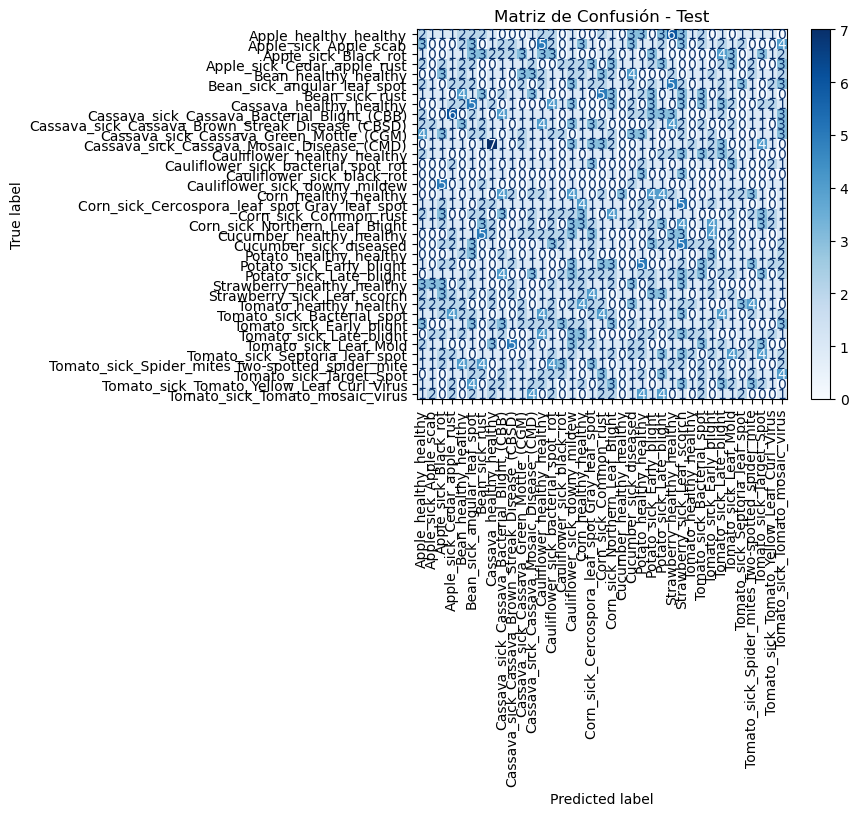

In [44]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
plt.figure(figsize=(200, 80))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Matriz de Confusión - Test")
plt.savefig("matriz_confusion_test_modelo_11.png", dpi=300, bbox_inches='tight')
plt.show()

In [45]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.0248


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 823ms/step


ValueError: num must be an integer with 1 <= num <= 12, not 13

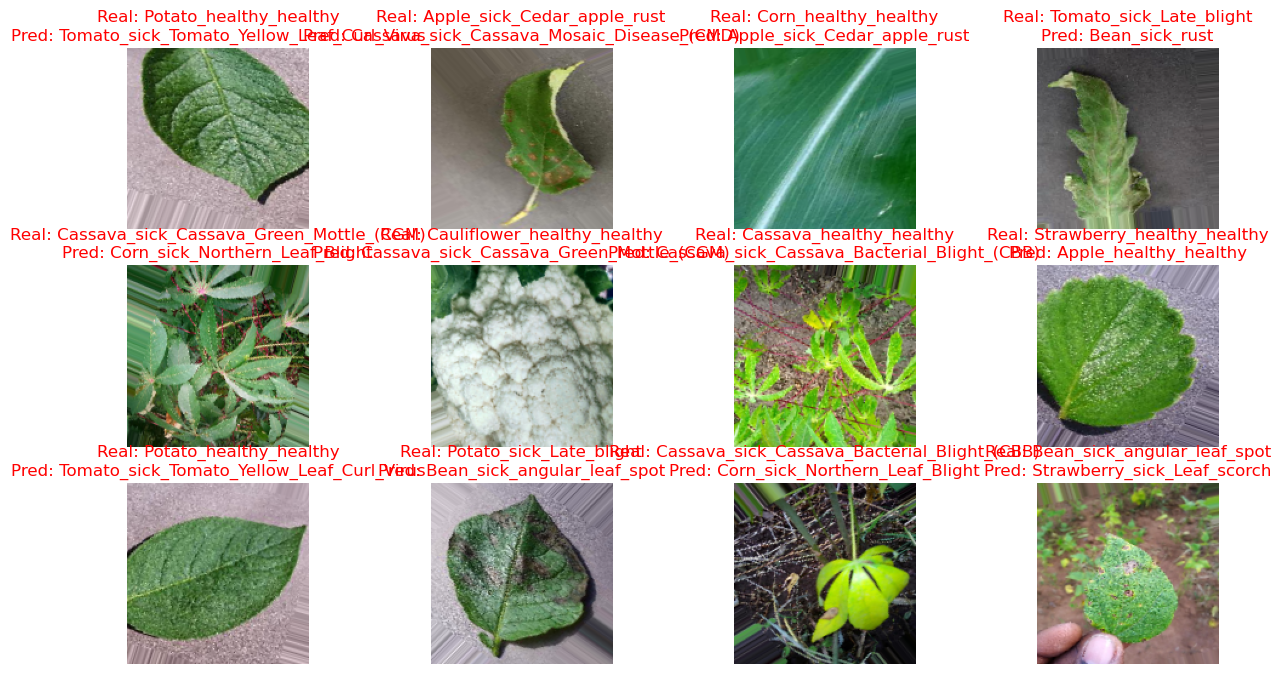

In [46]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

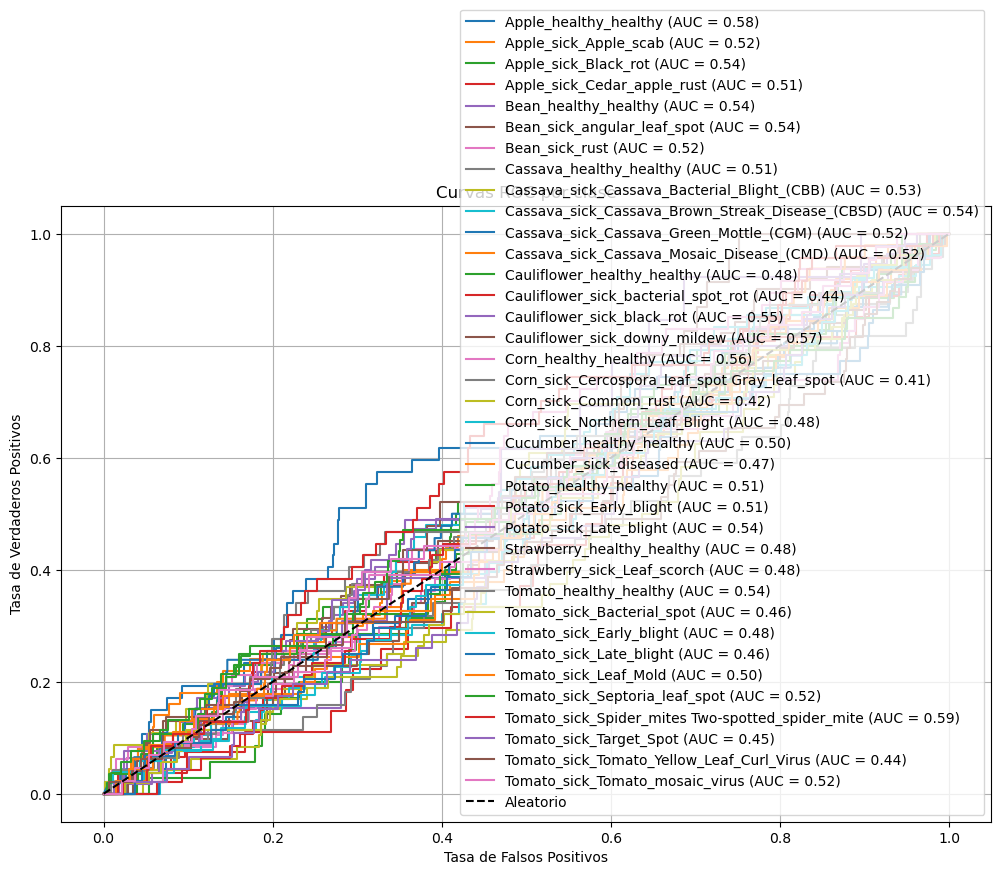

In [47]:
# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [49]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")


AUC Macro promedio: 0.5058
AUC Micro promedio: 0.4998


In [50]:
# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))


Accuracy: 0.0248
F1 Score (macro): 0.0247
F1 Score (micro): 0.0248
F1 Score (weighted): 0.0255

Reporte de clasificación por clase:
                                                  precision    recall  f1-score   support

                           Apple_healthy_healthy       0.05      0.04      0.04        47
                           Apple_sick_Apple_scab       0.00      0.00      0.00        50
                            Apple_sick_Black_rot       0.00      0.00      0.00        48
                     Apple_sick_Cedar_apple_rust       0.02      0.02      0.02        46
                            Bean_healthy_healthy       0.04      0.04      0.04        47
                     Bean_sick_angular_leaf_spot       0.03      0.04      0.04        51
                                  Bean_sick_rust       0.07      0.06      0.07        48
                         Cassava_healthy_healthy       0.05      0.04      0.04        48
     Cassava_sick_Cassava_Bacterial_Blight_(CBB)       0.

## 16. Guardar el modelo entrenado

In [54]:
model.save('modelo_11_resnet50_fine_tuned_balanceado_enfermedades.h5')

In [55]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}